In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# sklearn MLP baseline
from sklearn.neural_network import MLPClassifier

# Keras / TensorFlow MLPs
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Pretty printing of tables
pd.set_option("display.max_colwidth", 120)


In [3]:
# ===================================
# 1) Load Data (Jupyter Notebook version)
# ===================================

import pandas as pd

# If the CSV file is in the same folder as the notebook:
CSV_PATH = "pipline3.csv"

# Read the dataset
df = pd.read_csv(CSV_PATH)

# Remove unwanted column if it exists
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Show basic info
print("✅ Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# Display first few rows
df.head()


✅ Dataset Loaded Successfully!
Shape: (16964, 19)

Columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'bmi_category', 'age_group', 'htn_heart_interaction', 'gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,bmi_category,age_group,htn_heart_interaction,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1.000000,0,0,0.208314,0.090909,0.022727,0,3,4,0,0,1,0,0,0,0,1,0,0
1,1.000000,1,0,0.381653,0.400000,0.272727,1,4,4,0,1,0,0,0,0,0,0,1,0
2,0.712212,0,0,0.353862,0.454545,0.045455,0,4,3,0,1,0,0,0,0,1,0,0,0
3,0.812312,1,0,0.233396,0.600000,0.359091,1,4,3,0,0,1,0,0,0,0,1,0,0
4,0.000000,0,0,0.039802,0.272727,0.022727,0,1,1,0,0,1,0,1,0,0,0,0,0


In [4]:
# ===================================
# 2) Split & Scale
# ===================================
TARGET = "diabetes"
assert TARGET in df.columns, f"Target '{TARGET}' not in columns: {df.columns.tolist()}"

X = df.drop(columns=[TARGET])
y = df[TARGET]

# If target is not numeric, encode
if y.dtype == 'O':
    y = LabelEncoder().fit_transform(y)

# Train/test with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Scale features (good for ANNs); with_mean=False is safe for sparse-ish matrices
scaler = StandardScaler(with_mean=False)
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

X_train.shape, X_test.shape, np.bincount(y_train.astype(int))


((13571, 18), (3393, 18), array([6785, 6786]))

In [5]:
# ===================================
# 3) Helper: evaluate and plot functions (used for ALL models)
# ===================================
def compute_metrics(y_true, y_hat, name):
    acc = accuracy_score(y_true, y_hat)
    prec = precision_score(y_true, y_hat, zero_division=0)
    rec = recall_score(y_true, y_hat, zero_division=0)
    f1 = f1_score(y_true, y_hat, zero_division=0)
    print(f"\n=== {name} — Classification Report ===")
    print(classification_report(y_true, y_hat, zero_division=0))
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

def plot_confusion(y_true, y_hat, title):
    cm = confusion_matrix(y_true, y_hat)
    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=True)
    ax.set_title(title)
    plt.show()

def plot_training_curves(history, title_prefix="Keras Model"):
    """history: Keras History object"""
    h = history.history
    if "accuracy" in h and "val_accuracy" in h:
        plt.figure()
        plt.plot(h["accuracy"])
        plt.plot(h["val_accuracy"])
        plt.title(f"{title_prefix} — Accuracy")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy")
        plt.legend(["train","val"])
        plt.show()

    if "loss" in h and "val_loss" in h:
        plt.figure()
        plt.plot(h["loss"])
        plt.plot(h["val_loss"])
        plt.title(f"{title_prefix} — Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss")
        plt.legend(["train","val"])
        plt.show()



=== sklearn_MLP(64,32) — Classification Report ===
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      1697
           1       0.90      0.88      0.89      1696

    accuracy                           0.89      3393
   macro avg       0.89      0.89      0.89      3393
weighted avg       0.89      0.89      0.89      3393



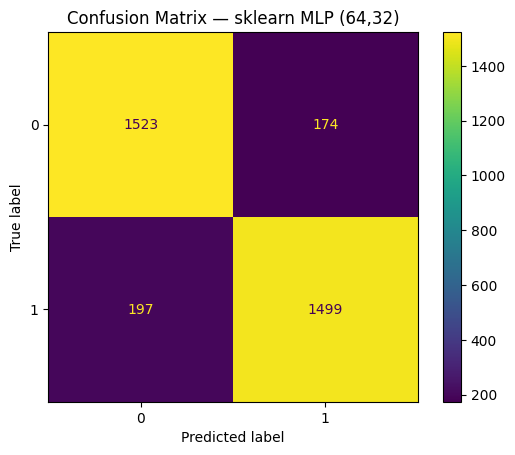

In [6]:
# ===================================
# 4) sklearn MLP Baseline (ANN)
# ===================================
sk_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.15,
    random_state=SEED
)
sk_mlp.fit(X_train_s, y_train)
y_hat_sk = sk_mlp.predict(X_test_s)

sk_metrics = compute_metrics(y_test, y_hat_sk, "sklearn_MLP(64,32)")
plot_confusion(y_test, y_hat_sk, "Confusion Matrix — sklearn MLP (64,32)")


In [7]:
# ===================================
# 5) Keras: model builder
# ===================================
def build_mlp(input_dim, hidden_layers=(128, 64), dropout=0.3, lr=1e-3):
    model = Sequential()
    # First hidden
    model.add(Dense(hidden_layers[0], activation='relu', input_shape=(input_dim,)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    # Additional hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
    # Output for binary classification
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)


In [8]:
# ===================================
# 6) Define Keras model "varieties" (no best selection)
# ===================================
input_dim = X_train_s.shape[1]

keras_configs = [
    {"name": "keras_(128,64)_drop0.3_lr1e-3",   "layers": (128,64),    "dropout": 0.30, "lr": 1e-3,  "epochs": 60, "batch": 128},
    {"name": "keras_(256,128)_drop0.3_lr1e-3",  "layers": (256,128),   "dropout": 0.30, "lr": 1e-3,  "epochs": 60, "batch": 128},
    {"name": "keras_(128,64,32)_drop0.4_lr5e-4","layers": (128,64,32), "dropout": 0.40, "lr": 5e-4, "epochs": 80, "batch": 128},
]



Training: keras_(128,64)_drop0.3_lr1e-3


C:\Users\hansi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== keras_(128,64)_drop0.3_lr1e-3 — Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1697
           1       0.88      0.92      0.90      1696

    accuracy                           0.90      3393
   macro avg       0.90      0.90      0.90      3393
weighted avg       0.90      0.90      0.90      3393



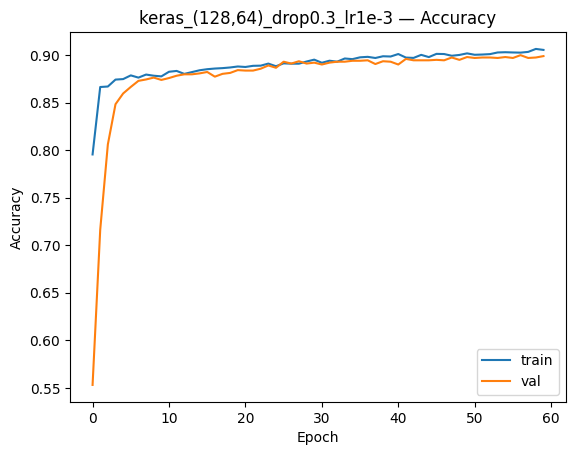

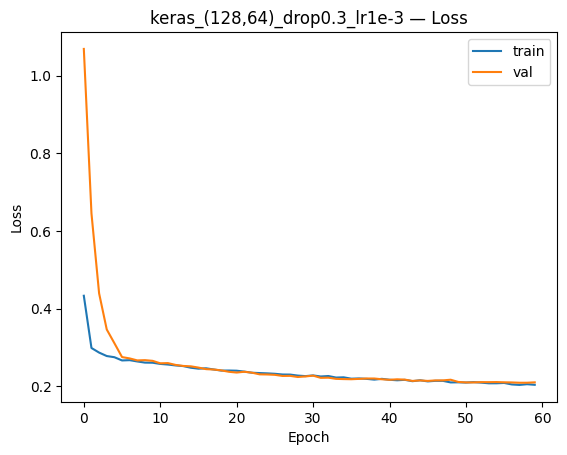

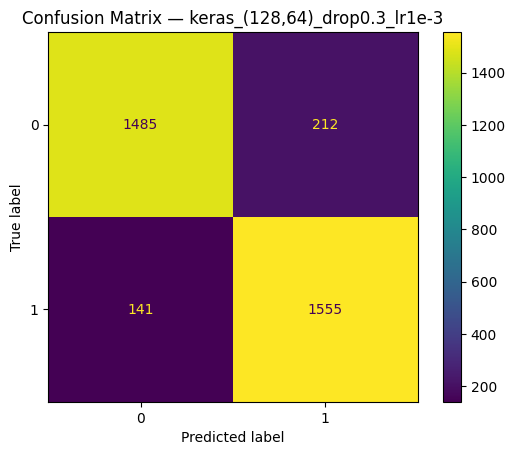


Training: keras_(256,128)_drop0.3_lr1e-3


C:\Users\hansi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== keras_(256,128)_drop0.3_lr1e-3 — Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.14      0.25      1697
           1       0.54      1.00      0.70      1696

    accuracy                           0.57      3393
   macro avg       0.77      0.57      0.47      3393
weighted avg       0.77      0.57      0.47      3393



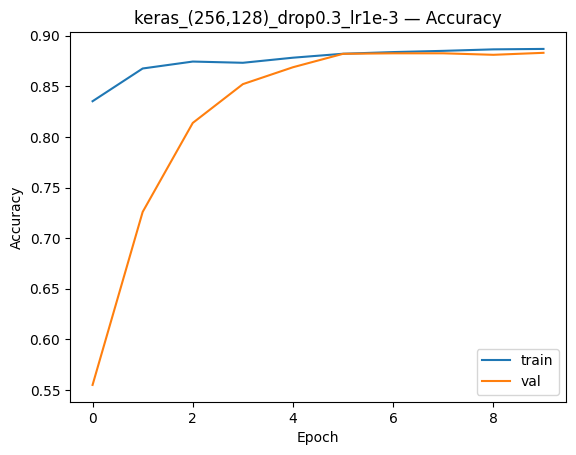

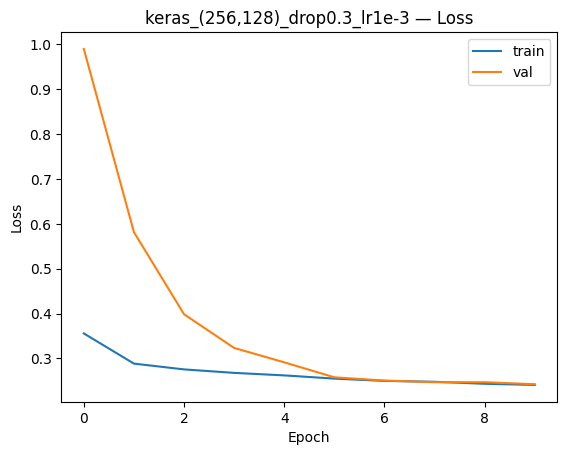

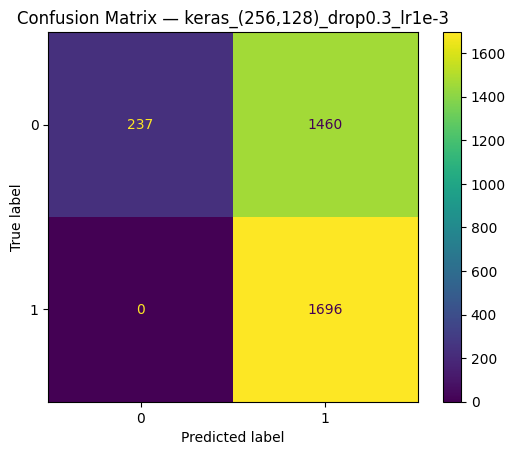


Training: keras_(128,64,32)_drop0.4_lr5e-4


C:\Users\hansi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== keras_(128,64,32)_drop0.4_lr5e-4 — Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.15      0.27      1697
           1       0.54      1.00      0.70      1696

    accuracy                           0.58      3393
   macro avg       0.77      0.58      0.48      3393
weighted avg       0.77      0.58      0.48      3393



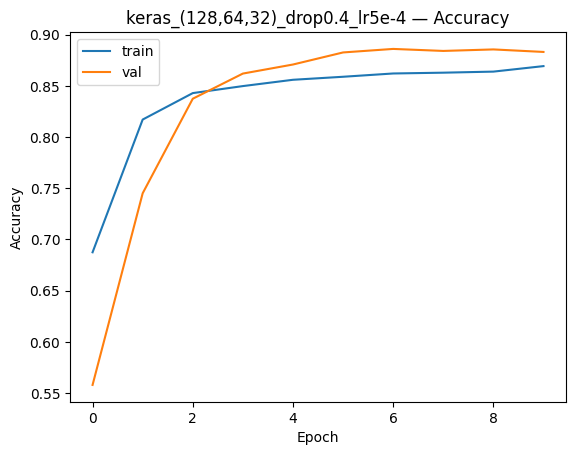

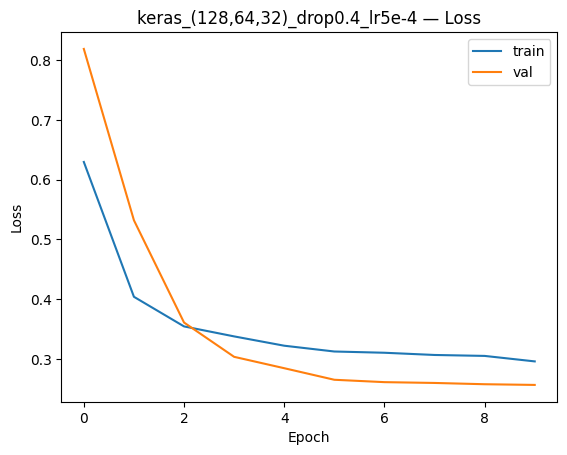

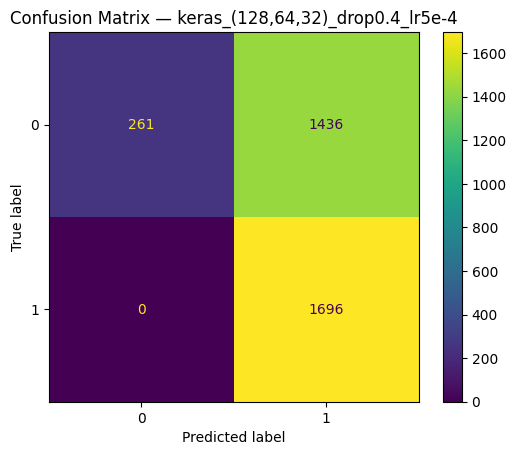


==== Summary of ALL models (no best picked) ====



,Model,Accuracy,Precision,Recall,F1
0,"sklearn_MLP(64,32)",0.8907,0.8960,0.8838,0.8899
1,"keras_(128,64)_drop0.3_lr1e-3",0.8960,0.8800,0.9169,0.8981
2,"keras_(256,128)_drop0.3_lr1e-3",0.5697,0.5374,1.0000,0.6991
3,"keras_(128,64,32)_drop0.4_lr5e-4",0.5768,0.5415,1.0000,0.7026


In [9]:
# ===================================
# 7) Train ALL Keras variants and show their OWN plots & reports
#    (no picking/saving "best" here)
# ===================================
all_metrics = []

for cfg in keras_configs:
    print("\n" + "="*80)
    print("Training:", cfg["name"])
    print("="*80)
    model = build_mlp(input_dim, hidden_layers=cfg["layers"], dropout=cfg["dropout"], lr=cfg["lr"])

    history = model.fit(
        X_train_s, y_train,
        validation_split=0.15,
        epochs=cfg["epochs"],
        batch_size=cfg["batch"],
        callbacks=[early, rlr],
        verbose=0
    )

    # Predictions for this model
    y_prob = model.predict(X_test_s, verbose=0).ravel()
    y_hat  = (y_prob >= 0.5).astype(int)

    # Metrics + report
    m = compute_metrics(y_test, y_hat, cfg["name"])
    all_metrics.append(m)

    # Per-model plots
    plot_training_curves(history, title_prefix=cfg["name"])
    plot_confusion(y_test, y_hat, f"Confusion Matrix — {cfg['name']}")

# Also add sklearn baseline to the metrics table
all_metrics.insert(0, sk_metrics)

summary_df = pd.DataFrame(all_metrics).round(4)
print("\n==== Summary of ALL models (no best picked) ====\n")
display(summary_df)
